In [1]:
import numpy as np
import pandas as pd

In [100]:
seed = 1
n_cells = (500, 250, 250)
n_genes = (50, 250, 250)
model = "poisson"
meanlog = 0.0
sdlog=0.25
scale=25.0
max_t = 15.0
sparsity = 0.0
theta=10.0
sort_times = True

#### Step 1: Sample cell pseudotimes and gene peak times by process

In [101]:
rng = np.random.default_rng(seed)
n_proc = len(n_cells)

cell_pt_list = []
gene_pt_list = []

for i in range(n_proc):
    cell_pt = rng.uniform(0, 1, size=n_cells[i])
    gene_pt = rng.uniform(0, 1, size=n_genes[i])
    
    if sort_times:
        cell_pt = np.sort(cell_pt)
        gene_pt = np.sort(gene_pt)
    
    cell_pt_list.append(cell_pt)
    gene_pt_list.append(gene_pt)
    
total_cells = sum(n_cells)
total_genes = sum(n_genes)

#### Step 2: Build process-coordinate matrics

In [102]:
cell_pt_mat = np.zeros((n_proc, total_cells), dtype=float)
gene_pt_mat = np.zeros((n_proc, total_genes), dtype=float)

# first process defaults to max_t
cell_pt_mat[0,:] = max_t
gene_pt_mat[0,:] = max_t

# fill parent process
cell_pt_mat[0, :n_cells[0]] = cell_pt_list[0]
gene_pt_mat[0, :n_genes[0]] = gene_pt_list[0]

cell_offsets = np.cumsum((0,)+tuple(n_cells))
gene_offsets = np.cumsum((0,)+tuple(n_genes))

# fill daughter processes
for i in range(1, n_proc):
    c0, c1 = cell_offsets[i], cell_offsets[i+1]
    g0, g1 = gene_offsets[i], gene_offsets[i+1]
    cell_pt_mat[i, c0:c1] = cell_pt_list[i]
    gene_pt_mat[i, g0:g1] = gene_pt_list[i]

#### Step 3: Sample gene-specific width (sigma) and amplitude (alpha)

In [103]:
sigma = 2.0 * rng.lognormal(mean=meanlog, sigma=sdlog, size=total_genes)
alpha = scale * rng.lognormal(mean=meanlog, sigma=sdlog, size=total_genes)

#### Step 4: Compute expectation matrix using gaussian-like decay

In [104]:
expectations = np.zeros((total_genes, total_cells), dtype=float)

for i in range(total_genes):
    gene_coord = gene_pt_mat[:, i][:,None]
    branch_mask = (gene_coord > 0).astype(int)

    dist = np.abs(cell_pt_mat - gene_coord)
    dist = dist * branch_mask  # 해당 branch만 중요하게
    dist = dist.sum(axis=0)
    
    
    lam = alpha[i] * np.exp(-dist**2 / (2*sigma[i]**2))
    expectations[i,:] = np.floor(lam)

#### Step 5: Sample counts

In [105]:
if model=="poisson":
    counts = rng.poisson(expectations)
elif model=="negbin":
    gamma_shape = theta
    gamma_scale = expectations / theta
    lam_nb = rng.gamma(shape=gamma_shape, scale=gamma_scale)
    counts = rng.poisson(lam_nb)
else:
    raise ValueError(f"Unsupported model: {model}")

#### Step 6: Optional sparsification

In [106]:
if sparsity is not None:
    flat = counts.ravel().astype(float)
    
    nonzero_frac = (flat > 0).mean()
    keep_frac = min(sparsity, nonzero_frac)
    
    if flat.sum() > 0 and keep_frac > 0:
        n_keep = int(np.floor(keep_frac * flat.size))
        probs = flat / flat.sum()
        
        choosen = rng.choice(
            np.arange(flat.size),
            size=n_keep,
            replace=False,
            p=probs
        )
        mask = np.zeros(flat.size, dtype=int)
        mask[choosen] = 1
        counts = flat.reshape(counts.shape)
        
    

#### Step 7: Build metadata

In [107]:
gene_names = [f"G{i+1}" for i in range(total_genes)]
cell_names = [f"C{i+1}" for i in range(total_cells)]

counts_df = pd.DataFrame(counts, index=gene_names, columns=cell_names)

cell_branch = (
    ["parent"] * n_cells[0] +
    ["branch1"] * n_cells[1] +
    ["branch2"] * n_cells[2]
)

cell_time = np.concatenate(cell_pt_list)

cell_meta = pd.DataFrame({
    "cell_id":cell_names,
    "branch":cell_branch,
    "pseudotime":cell_time
})

gene_branch = (
        ["parent_gene"] * n_genes[0] +
        ["branch1_gene"] * n_genes[1] +
        ["branch2_gene"] * n_genes[2]
    )
gene_peak = np.concatenate(gene_pt_list)

gene_meta = pd.DataFrame({
    "gene_id": gene_names,
    "gene_module": gene_branch,
    "peak_time": gene_peak,
    "sigma": sigma,
    "alpha": alpha
})

In [114]:
def plot_pseudotime_distribution(cell_meta):
    plt.figure(figsize=(6,4))
    sns.histplot(
        data=cell_meta,
        x="pseudotime",
        hue="branch",
        bins=30,
        kde=True
    )
    plt.title("Pseudotime distribution by branch")
    plt.show()
    
def plot_heatmap(counts, cell_meta, gene_meta, n_genes=100):
    
    # pseudotime 기준으로 cell 정렬
    order = np.argsort(cell_meta["pseudotime"].values)
    counts_sorted = counts.iloc[:, order]
    
    # gene 일부 선택
    subset = counts_sorted.iloc[:n_genes, :]
    
    plt.figure(figsize=(10,6))
    sns.heatmap(
        subset,
        cmap="viridis",
        cbar=True
    )
    plt.title("Gene expression heatmap (sorted by pseudotime)")
    plt.xlabel("Cells")
    plt.ylabel("Genes")
    plt.show()
    
def plot_branch_specific_genes(counts, cell_meta, gene_meta):
    
    # branch별 평균 expression
    merged = counts.T.copy()
    merged["branch"] = cell_meta["branch"].values
    
    branch_means = merged.groupby("branch").mean().T
    
    # top genes 선택
    top_genes = branch_means.var(axis=1).sort_values(ascending=False).head(10).index
    
    plt.figure(figsize=(8,5))
    
    for gene in top_genes:
        plt.plot(branch_means.columns, branch_means.loc[gene], marker='o', label=gene)
    
    plt.title("Branch-specific genes")
    plt.ylabel("Mean expression")
    plt.legend(bbox_to_anchor=(1.05,1))
    plt.show()

def plot_gene_trend(counts, cell_meta, gene_meta, n_genes=5):
    
    selected_genes = gene_meta.sort_values("peak_time").head(n_genes)["gene_id"]
    
    plt.figure(figsize=(8,5))
    
    for gene in selected_genes:
        plt.scatter(
            cell_meta["pseudotime"],
            counts.loc[gene],
            alpha=0.3,
            label=gene
        )
    
    plt.xlabel("Pseudotime")
    plt.ylabel("Expression")
    plt.title("Gene expression over pseudotime")
    plt.legend()
    plt.show()
    
from sklearn.decomposition import PCA

def plot_cells_pca(counts, cell_meta, log1p=True):
    """
    counts: gene x cell DataFrame
    cell_meta: DataFrame with columns ['cell_id', 'branch', 'pseudotime']
    """
    X = counts.T.values  # cell x gene

    if log1p:
        X = np.log1p(X)

    pca = PCA(n_components=2, random_state=0)
    emb = pca.fit_transform(X)

    plot_df = cell_meta.copy()
    plot_df["PC1"] = emb[:, 0]
    plot_df["PC2"] = emb[:, 1]

    plt.figure(figsize=(6, 5))

    for branch in plot_df["branch"].unique():
        sub = plot_df[plot_df["branch"] == branch]
        plt.scatter(
            sub["PC1"], sub["PC2"],
            s=14, alpha=0.7, label=branch
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Cells in PCA space")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_cells_pca_by_time(counts, cell_meta, log1p=True):
    X = counts.T.values  # cell x gene

    if log1p:
        X = np.log1p(X)
    from sklearn.preprocessing import StandardScaler

    X = np.log1p(counts.T.values)
    X = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2, random_state=0)
    emb = pca.fit_transform(X)

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(
        emb[:, 0], emb[:, 1],
        c=cell_meta["pseudotime"].values,
        s=14, alpha=0.8
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Cells in PCA space colored by pseudotime")
    plt.colorbar(sc, label="pseudotime")
    plt.tight_layout()
    plt.show()

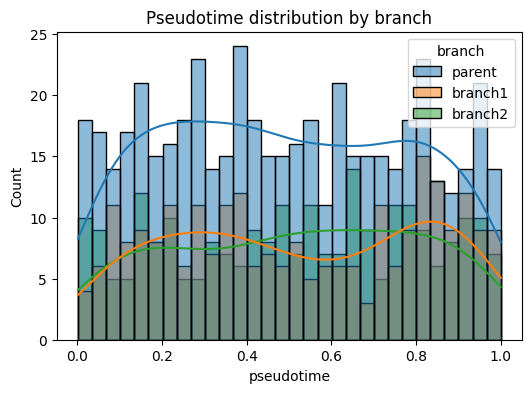

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_pseudotime_distribution(cell_meta)

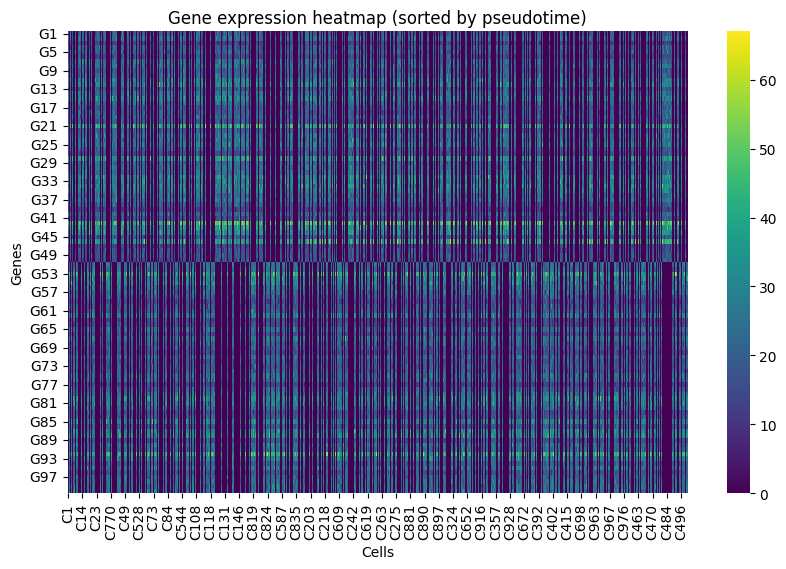

In [116]:
plot_heatmap(counts_df, cell_meta, gene_meta, n_genes=100)

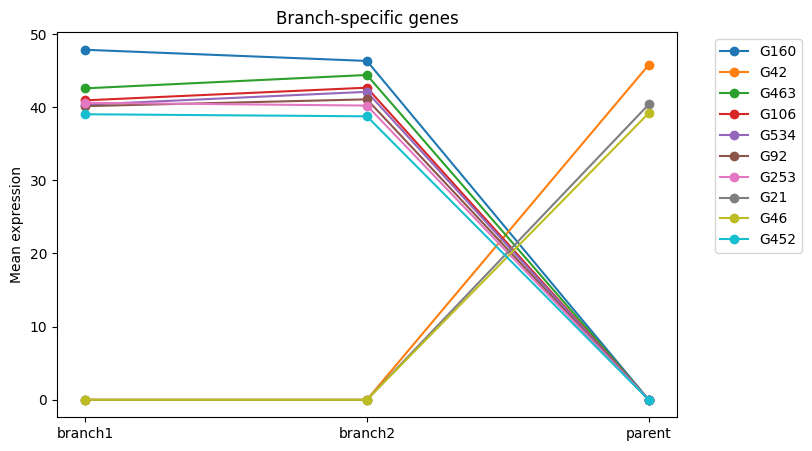

In [117]:
plot_branch_specific_genes(counts_df, cell_meta, gene_meta)

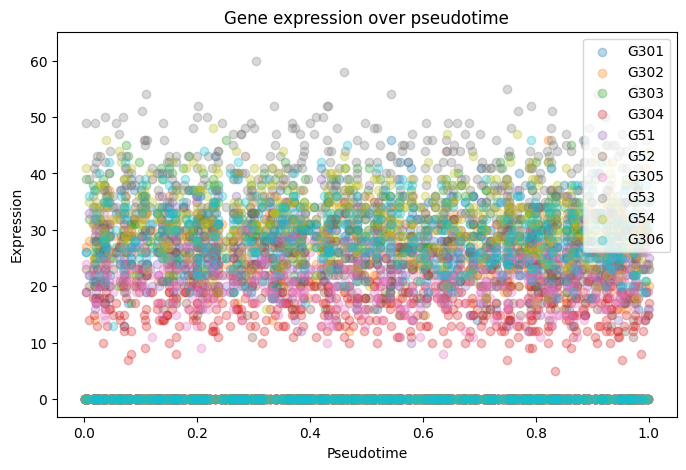

In [118]:
plot_gene_trend(counts_df, cell_meta, gene_meta, n_genes=10)

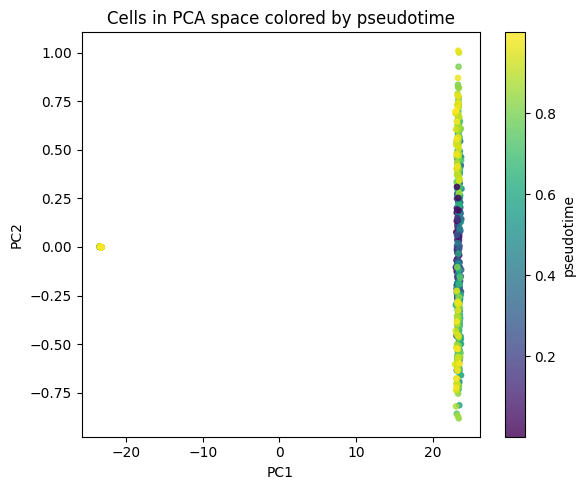

In [119]:
plot_cells_pca_by_time(counts_df, cell_meta)